# FlexTok: Resampling Images into 1D Token Sequences of Flexible Length

[`Website`](https://flextok.epfl.ch) | [`arXiv`](https://arxiv.org/abs/2502.13967) | [`GitHub`](https://github.com/apple/ml-flextok)

Official implementation for: <br>
[**FlexTok: Resampling Images into 1D Token Sequences of Flexible Length**](https://arxiv.org/abs/2502.13967), arXiv 2025 <br>
*[Roman Bachmann](https://roman-bachmann.github.io/)\*, [Jesse Allardice](https://github.com/JesseAllardice)\*, [David Mizrahi](https://dmizrahi.com/)\*, [Enrico Fini](https://scholar.google.com/citations?user=OQMtSKIAAAAJ), [Oğuzhan Fatih Kar](https://ofkar.github.io/), [Elmira Amirloo](https://elamirloo.github.io/), [Alaaeldin El-Nouby](https://aelnouby.github.io/), [Amir Zamir](https://vilab.epfl.ch/zamir/), [Afshin Dehghan](https://scholar.google.com/citations?user=wcX-UW4AAAAJ)*

FlexTok is a tokenizer that enables representing images as an ordered one-dimensional sequence of tokens. It consists of an ViT register encoder mapping images to token sequences, and a ViT register rectified flow decoder mapping token sequences back to images. The encoder and decoder operate on a VAE latent space, and this notebook contains both examples for FlexTok and VAE inference.

Please make sure to follow the installation instructions outlined in the official repository. We recommend running this notebook on A100s or H100s and to perform inference in `bfloat16`.

In [1]:
# Switch path to root of project
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
current_folder = globals()['_dh'][0]
os.chdir(os.path.dirname(os.path.abspath(current_folder)))

%load_ext autoreload
%autoreload 2

In [3]:
from PIL import Image
import matplotlib.pyplot as plt

import einops
import torch
import torchvision.transforms.functional as TF

from diffusers.models import AutoencoderKL

from flextok.flextok_wrapper import FlexTokFromHub
from flextok.utils.demo import imgs_from_urls, denormalize, batch_to_pil
from flextok.utils.misc import detect_bf16_support, get_bf16_context, get_generator

# The flag below controls whether to allow TF32 on matmul. This flag defaults to False in PyTorch 1.12 and later.
torch.backends.cuda.matmul.allow_tf32 = True
# The flag below controls whether to allow TF32 on cuDNN. This flag defaults to True.
torch.backends.cudnn.allow_tf32 = True

# Global no_grad
torch.set_grad_enabled(False)

# Automatically set device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)

# Detect if bf16 is enabled or not
enable_bf16 = detect_bf16_support()
print('BF16 enabled:', enable_bf16)

/BS/data_mani_compress/work/miniforge3/envs/dgm_geometry/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
BF16 enabled: True


## 1 Loading example images

We load several demo images to showcase FlexTok and VAE reconstructions for. Feel free to use your own images!

When working with ImageNet-style images, we recommend loading the dedicated ImageNet FlexTok models, while for all other cases we recommend the DFN version.

Loaded images:


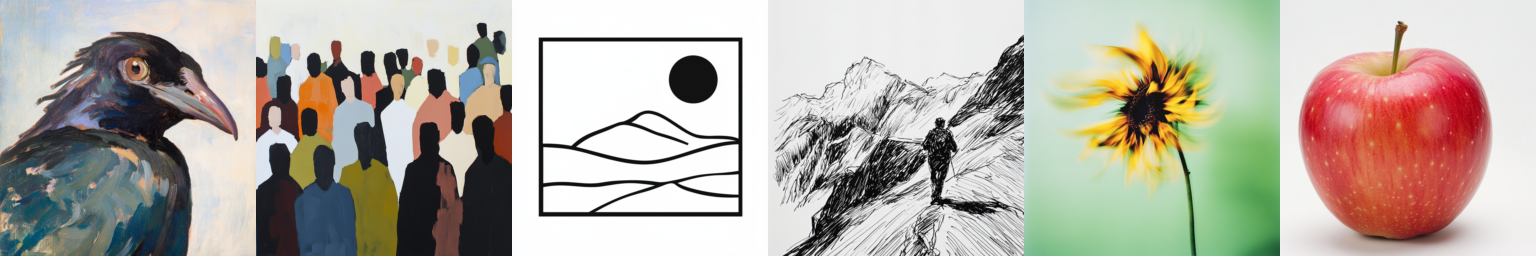

In [4]:
imgs = imgs_from_urls([
    f'https://storage.googleapis.com/flextok_site/nb_demo_images/{i}.png' 
    for i in range(6)
]).to(device)
print('Loaded images:')
batch_to_pil(imgs)

## 2 FlexTok inference

The FlexTok encoder maps an image into a one-dimensional sequence of 256 register tokens. These tokens are discretized using FSQ, resulting in a vocabulary of 64,000 tokens.

FlexTok was trained so that these quantized register tokens represent images in a hierarchical and ordered manner. Specifically, truncated subsequences of lengths _1, 2, 4, 8, 16, 32, 64, 128, and 256_ tokens all represent valid images, and as more tokens are used, the reconstructions increasingly resemble the encoded image. Although FlexTok was trained solely using a rectified flow and REPA objective, the truncated token sequences emerge as highly semantic compressions of the original image, capturing its most salient aspects with the fewest tokens.

To showcase this, we load here our largest FlexTok tokenizer (18 encoder layers, 28 decoder layers) trained on DFN. We load it directly from HuggingFace Hub. Please see the official repository for instructions on how to load models manually.

**Warning**: Executing the following cell will download a 10.2 GB model. This may take a while depending on your connection.

In [13]:
# Load a FlexTok d18-d28 model trained on DFN from HuggingFace Hub
flextok = FlexTokFromHub.from_pretrained('EPFL-VILAB/flextok_d18_d18_in1k').to(device).eval()

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


### 2.1 Autoencoding using all 256 tokens

First, a simple example of autoencoding images using FlexTok. We tokenize images into 256 tokens each using the FlexTok encoder. The first time this cell is run might take some time, but subsequent executions should be faster.

In [14]:
with get_bf16_context(enable_bf16):
    tokens_list = flextok.tokenize(imgs) # List of [1, 256] discrete token sequences

In [15]:
print(type(tokens_list), len(tokens_list))
print(tokens_list[0].shape)  # Each element is a [1, 256] tensor
print(tokens_list[0])  

<class 'list'> 6
torch.Size([1, 256])
tensor([[ 3556,   776, 23020, 63123,  7467, 12996, 21579,  6883,  9081,  1875,
         13275, 23540, 43947, 13723,  8507, 19215,  3044, 51552, 30184, 15147,
         63690, 17054,  6629, 25887, 25850,  6621, 11934, 16304, 29315, 49985,
         34881, 34312,   987, 29365, 51545,  4435,  6116,  3924,  6629,  1867,
          3043, 41319, 31971,  6629,  1867, 36473, 13779, 34128, 54439, 31199,
         18052,   776, 44684, 32527,  3084, 12072, 62910, 17753,  6953, 53003,
          6629, 39717,  6939, 44772, 20239,  4434, 18552, 12569,  4069, 56383,
         54499,  3043,  6629, 40089,  3556, 58207,  6045,  9151,   986, 39359,
          6621, 19251, 39144, 61915, 60585, 22081,  1867, 25981, 16652,   864,
          6445, 31425,  5604, 45423, 13087,  6629, 39695, 46349, 60068, 48077,
         37594,   704, 51932,  1875, 25916, 19236, 18812, 51099, 55252, 36781,
         29263, 27371, 35035, 51324,  6621, 17179, 17856, 42795, 52943, 50059,
         52003

Then , we detokenize all 256 register tokens back into images using the FlexTok rectified flow decoder. There are three important hyperparameters for the rectified flow decoder:

- `timesteps`: Number of denoising steps. 25 steps provides a good balance between reconstruction quality and inference speed.
- `guidance_scale`: Classifier-free guidance scale. See the paper appendix for guidance scale sweeps for all models. We recommend guidance scale 7.5, except for the FlexTok d12-d12 model where we recommend guidance scale 15.
- `perform_norm_guidance`: Whether or not to perform Adaptive Projected Guidance (APG), see https://arxiv.org/abs/2410.02416. We recommend setting this to True.

In [50]:

import time

start = time.time()
with get_bf16_context(enable_bf16):
    reconst = flextok.detokenize(
        [tokens_list[0]],
        timesteps=25, # Number of denoising steps
        guidance_scale=7.5, # Classifier-free guidance scale
        perform_norm_guidance=True, # APG, see https://arxiv.org/abs/2410.02416
         # Optionally control initial noise. Note that while the initial noise is deterministic, the rest of the model isn't.
        generator=get_generator(seed=0, device=device),
        verbose=False, # Enable to show denoising progress bar with tqdm
    )
end = time.time()

print(f"Elapsed time: {end - start:.4f} seconds")

Elapsed time: 1.1972 seconds


In [20]:
# read npz file at /BS/latent-diffusion/work/ml-flextok/latents_d18_d18.npz
import numpy as np

data = np.load("/BS/latent-diffusion/work/ml-flextok/latents_d18_d18.npz")

# List all arrays stored inside
print(data.files)    # e.g. ['arr1', 'arr2', 'arr3']



['data', 'labels']


In [23]:
print(data['data'].shape)  
print(data['labels'].shape)  

(1281167, 1536)
(1281167,)


In [52]:
# reshape data['data'] to (1281167, 256, 6)
tokens_rearranged = data['data'].reshape(1281167, 256, 6)


Reconstructions using all 256 tokens:


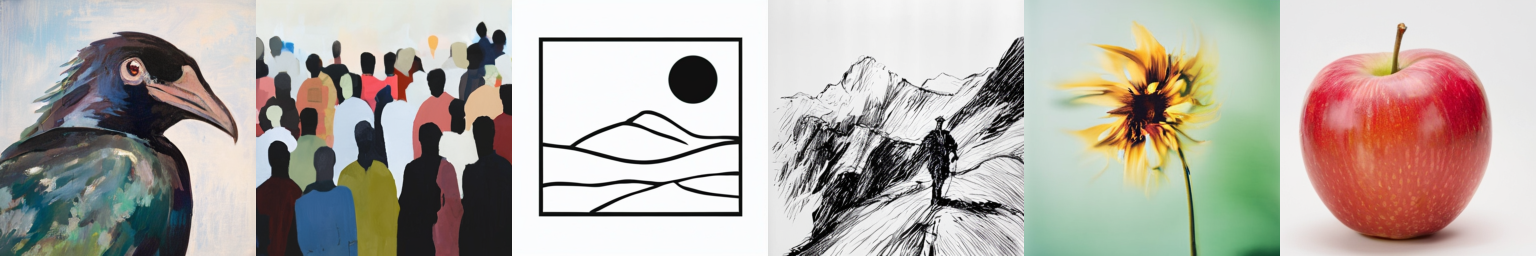

In [ ]:

print('Reconstructions using all 256 tokens:')
batch_to_pil(reconst)

### 2.2 Flexible-length tokenization

Now we encode each image once and show reconstructions from the first _1, 2, 4, ..., 256_ tokens. Practically this means truncating the token sequences from the right, keeping only the chosen number of tokens, and running the rectified flow decoder on only that subset of tokens.

In [12]:
def plot_flexible_length_reconsts(imgs, k_keep_list, figscale=3.0, seed=None):
    # Tokenize images once
    with get_bf16_context(enable_bf16):
        tokens_list = flextok.tokenize(imgs) # List of [1, 256] discrete token sequences
        
    # Detokenize various subsequences
    all_reconst = {}
    for k_keep in k_keep_list:
        # Simply truncate the token sequences from the right
        subseq_list = [seq[:,:k_keep].clone() for seq in tokens_list]
        with get_bf16_context(enable_bf16):
            generator = get_generator(seed=seed, device=device)
            all_reconst[k_keep] = flextok.detokenize(
                subseq_list, timesteps=25, 
                guidance_scale=7.5, perform_norm_guidance=True,
                generator=generator, verbose=False,
            )
    
    # Plotting
    ncols = len(k_keep_list) + 1 # 1 | 2 | 4 | ... | 256 | GT
    nrows = imgs.shape[0]

    fig, axes = plt.subplots(nrows, ncols, figsize=(figscale*ncols, figscale*nrows))
    axes = [axes] if nrows == 1 else axes
    
    imgs_plot = denormalize(imgs)
    all_reconst = {k_keep: denormalize(rec).clamp(0,1) for k_keep, rec in all_reconst.items()}
    
    for img_idx in range(nrows):
        for col_idx, k_keep in enumerate(k_keep_list):
            axes[img_idx][col_idx].imshow(TF.to_pil_image(all_reconst[k_keep][img_idx]))
        axes[img_idx][-1].imshow(TF.to_pil_image(imgs_plot[img_idx]))
        
        for ax in axes[img_idx]:
            ax.axis("off")

    for col_idx, k_keep in enumerate(k_keep_list):
        title = f'{k_keep} token' + ('' if k_keep == 1 else 's')
        axes[0][col_idx].set_title(title, fontsize=18)
    axes[0][-1].set_title('Groundtruth', fontsize=18)

    plt.tight_layout()
    plt.show()

Below are the reconstructions from various subsequences. Even with a high degree of compression (each token can only be one of 64'000 classes, i.e. takes up 2 bytes), the reconstructions capture the most important high-level semantic and geometric information first. In the first example, with merely 4 tokens FlexTok captures the essence of a painted bird looking towards the right. 

Depending on the image complexity, different number of tokens are required to faithfully reconstruct the given images. For example, simple images that contain only one central object (like the apple) can be reconstructed well with as few as 1-16 tokens. By this we mean that the main concept, here "single apple in front of neutral background" is faithfully captured, while details like the length of the stem or texture on the fruit are abstracted away. On the other hand, more complex scenes like the image of a crowd of people requires 64-256 tokens to capture the position and clothing of each person, while the gist of the scene is captured by only 4 tokens.

In [ ]:
k_keep_list = [1, 2, 4, 8, 16, 32, 64, 128, 256]
plot_flexible_length_reconsts(imgs, k_keep_list, seed=0)


--- Sample 0 ---
Register shape: torch.Size([1, 256, 6])
Kept tokens: 1


OutOfMemoryError: CUDA out of memory. Tried to allocate 74.00 MiB. GPU 0 has a total capacity of 23.68 GiB of which 82.94 MiB is free. Process 835572 has 11.60 GiB memory in use. Including non-PyTorch memory, this process has 11.02 GiB memory in use. Of the allocated memory 10.27 GiB is allocated by PyTorch, and 455.69 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

: 

## 3 VAE-GAN inference

All FlexTok models operate on top of a VAE-GAN latent space, similar to the one of SDXL. Similar to SD3's findings, we found the 4-channel SDXL VAE-GAN compression to be too strong for subsequent use and decided to train our own VAE-GAN models with 4, 8, and 16 channels and a downsampling factor of 8. For all FlexTok models we used the 16-channel version.

In the following we show how to load our VAE-GAN models and autoencode the loaded images.

### 3.1 Helper functions

In [ ]:
def vae_encode(imgs, vae_model):
    scaling_factor = vae_model.config['scaling_factor']
    return vae_model.encode(imgs).latent_dist.sample() * scaling_factor

def vae_decode(latents, vae_model):
    scaling_factor = vae_model.config['scaling_factor']
    return vae_model.decode(latents / scaling_factor).sample

def plot_vae_reconst(imgs, reconst_sdxl_c4, reconst_c4, reconst_c8, reconst_c16, figscale=3.0):
    ncols = 5 # SDXL ch4 | ch4 | ch8 | ch16 | GT
    nrows = imgs.shape[0]

    fig, axes = plt.subplots(nrows, ncols, figsize=(figscale*ncols, figscale*nrows))
    axes = [axes] if nrows == 1 else axes
    
    imgs_plot = denormalize(imgs)
    reconst_sdxl_c4_plot = denormalize(reconst_sdxl_c4).clamp(0,1)
    reconst_c4_plot = denormalize(reconst_c4).clamp(0,1)
    reconst_c8_plot = denormalize(reconst_c8).clamp(0,1)
    reconst_c16_plot = denormalize(reconst_c16).clamp(0,1)
    
    for img_idx in range(nrows):
        axes[img_idx][0].imshow(TF.to_pil_image(reconst_sdxl_c4_plot[img_idx]))
        axes[img_idx][1].imshow(TF.to_pil_image(reconst_c4_plot[img_idx]))
        axes[img_idx][2].imshow(TF.to_pil_image(reconst_c8_plot[img_idx]))
        axes[img_idx][3].imshow(TF.to_pil_image(reconst_c16_plot[img_idx]))
        axes[img_idx][4].imshow(TF.to_pil_image(imgs_plot[img_idx]))

        for ax in axes[img_idx]:
            ax.axis("off")

    axes[0][0].set_title('4-channel SDXL VAE')
    axes[0][1].set_title('4-channel FlexTok VAE')
    axes[0][2].set_title('8-channel FlexTok VAE')
    axes[0][3].set_title('16-channel FlexTok VAE')
    axes[0][4].set_title('GT')

    plt.tight_layout()
    plt.show()

### 3.2 Load VAE-GAN models

All VAE-GAN models use the same architecture as the SDXL VAE, but differ in the number of latent channels. They can be loaded from HuggingFace Hub using `diffusers.models.AutoencoderKL`. 

In [ ]:
vae_c4  = AutoencoderKL.from_pretrained('EPFL-VILAB/flextok_vae_c4', low_cpu_mem_usage=False).to(device).eval()
vae_c8  = AutoencoderKL.from_pretrained('EPFL-VILAB/flextok_vae_c8', low_cpu_mem_usage=False).to(device).eval()
vae_c16 = AutoencoderKL.from_pretrained('EPFL-VILAB/flextok_vae_c16', low_cpu_mem_usage=False).to(device).eval()

We also load a baseline SDXL VAE for comparison:

In [ ]:
vae_sdxl_c4 = AutoencoderKL.from_pretrained('stabilityai/sdxl-vae', low_cpu_mem_usage=False).to(device).eval()

### 3.3 Plot reconstructions

In the following, we show reconstructions from each VAE. The VAEs map images of size 256x256 pixels to a 4, 8, or 16 channel latent space of height and width 32x32.

In [ ]:
reconst_c4  = vae_decode(vae_encode(imgs, vae_c4), vae_c4)
reconst_c8  = vae_decode(vae_encode(imgs, vae_c8), vae_c8)
reconst_c16 = vae_decode(vae_encode(imgs, vae_c16), vae_c16)

reconst_sdxl_c4  = vae_decode(vae_encode(imgs, vae_sdxl_c4), vae_sdxl_c4)

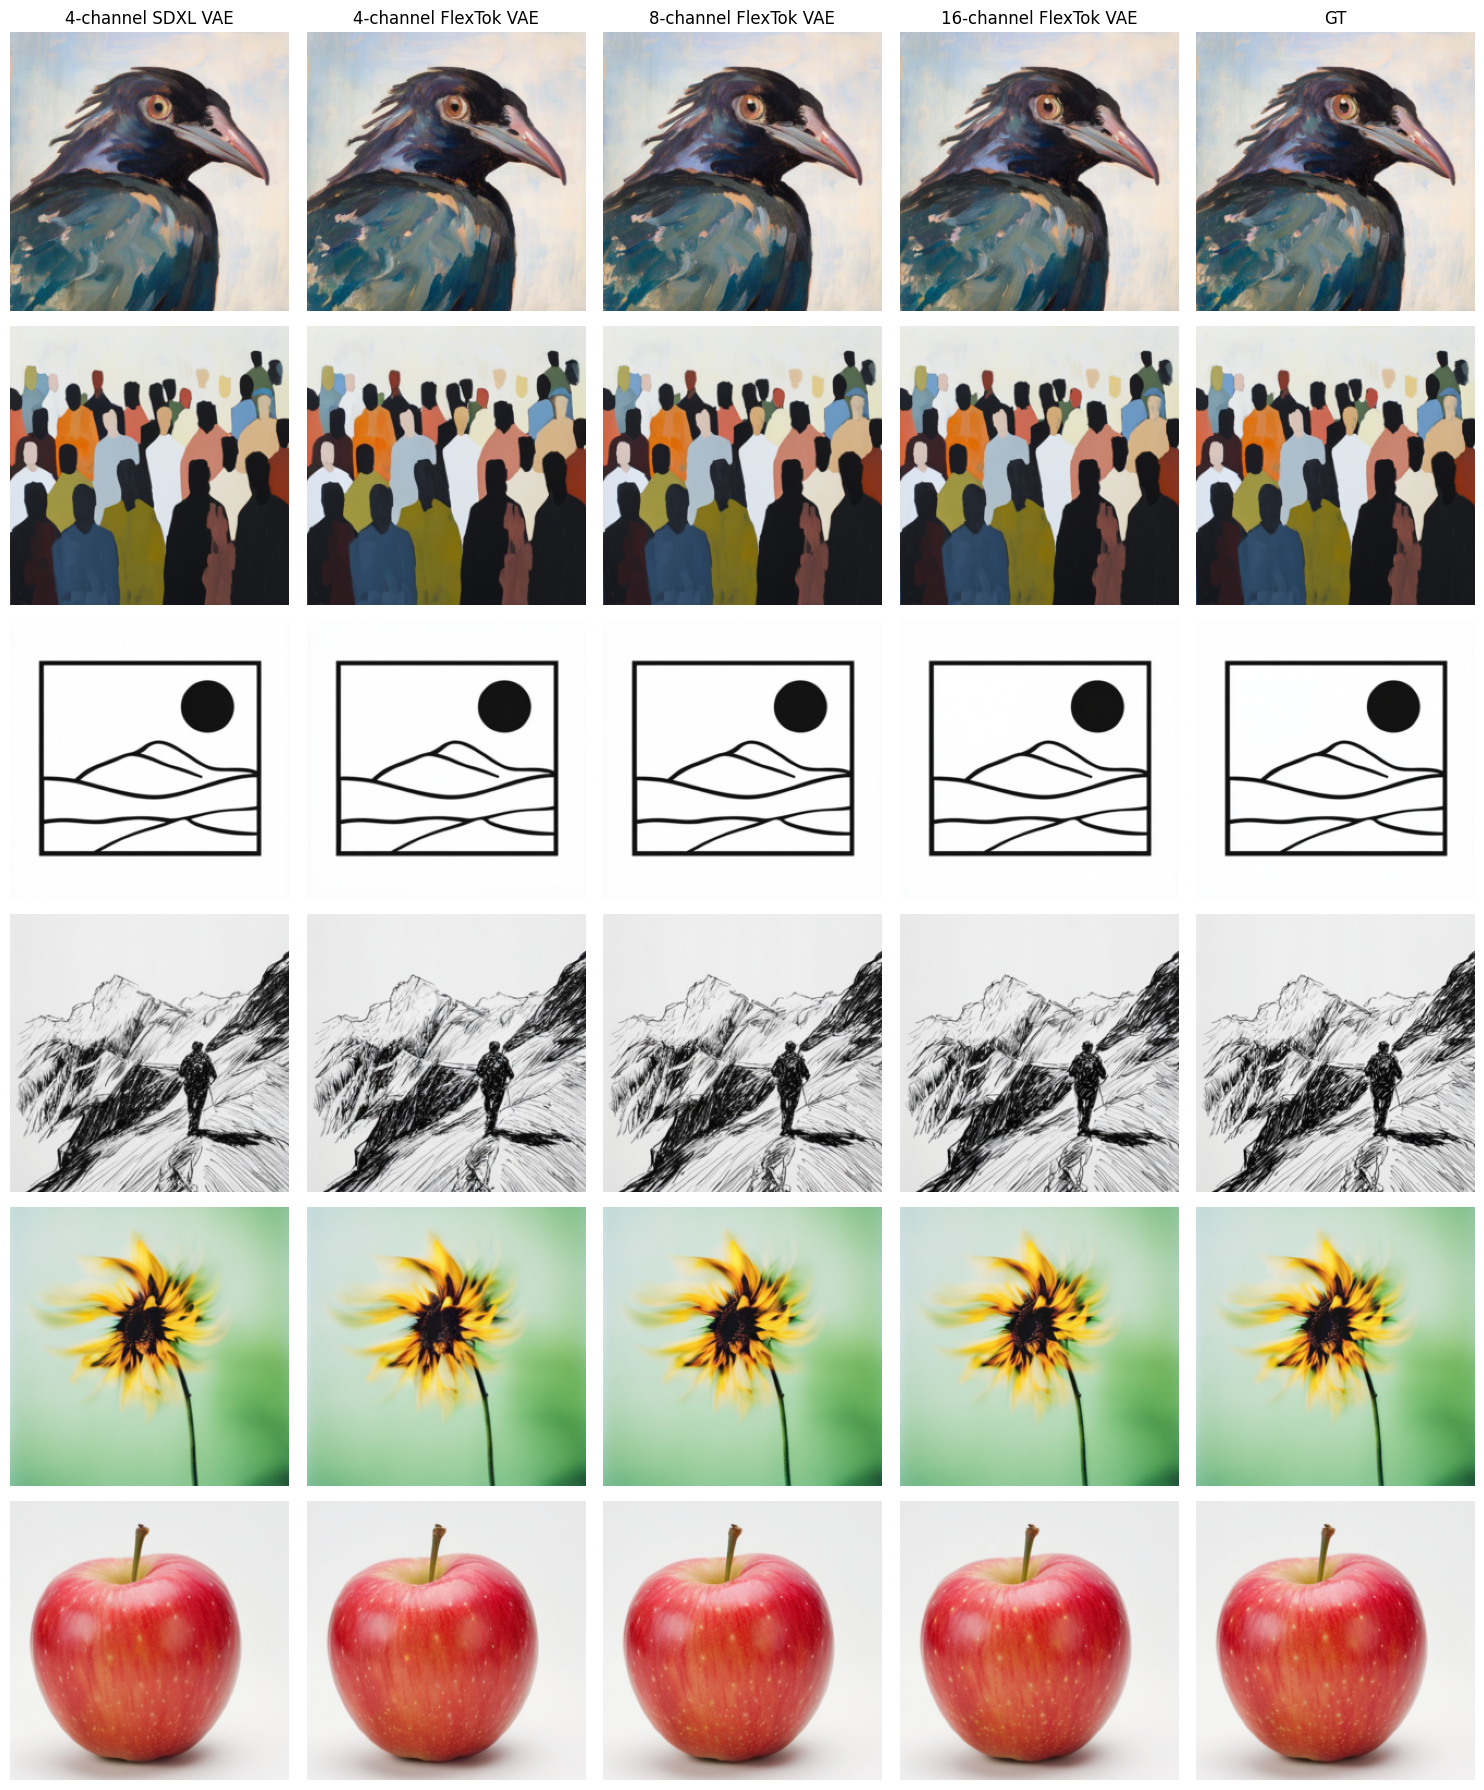

In [ ]:
plot_vae_reconst(imgs, reconst_sdxl_c4, reconst_c4, reconst_c8, reconst_c16)

### Map 6D FSQ codes to discrete register IDs (and back)

The FSQ module discretizes each 6-D register code to one of 64k mixed-radix codes with levels [8,8,8,5,5,5].
Below we convert a 6-D code sequence to integer token IDs via `codes_to_indices`, and verify the inverse with `indices_to_embedding`.


In [55]:
import torch
from flextok.regularizers.quantize_fsq import FSQ

# FSQ levels used by FlexTok (vocab size 8*8*8*5*5*5 = 64,000)
levels = [8, 8, 8, 5, 5, 5]
fsq = FSQ(
    latents_read_key="_dummy_in_",
    quants_write_key="_dummy_quants_",
    tokens_write_key="_dummy_tokens_",
    levels=levels,
)

# tokens_rearranged has shape [N, 256, 6]; convert the first example to ids
codes_np = tokens_rearranged  # from previous cell
idx = 0  # choose which sample to convert
codes = torch.from_numpy(codes_np[idx]).to(torch.float32)  # [256, 6], values in ~[-1, 1]

# Optional: snap to the FSQ grid before index mapping (robust if inputs are slightly off-grid)
half = (torch.tensor(levels, dtype=torch.float32) // 2)  # [6]
codes = torch.clamp(codes, -1.0, 1.0)
codes_q = torch.round(codes * half) / half

# Convert 6-D codes -> integer token IDs in [0 .. 63999]
ids = fsq.codes_to_indices(codes_q)  # [256], dtype long
print("ids shape:", ids.shape)
print("first 16 ids:", ids[:16].tolist())

# Verify inverse: IDs -> back to 6-D codes on the FSQ grid
codes_back = fsq.indices_to_embedding(ids)  # [256, 6]
print("max abs diff to quantized codes:", (codes_back - codes_q).abs().max().item())

# If desired, you can feed `ids.unsqueeze(0)` (shape [1, 256]) to flextok.detokenize
# reconst_from_npz = flextok.detokenize([ids.unsqueeze(0)], timesteps=25, guidance_scale=7.5, perform_norm_guidance=True)
# batch_to_pil(reconst_from_npz)


ids shape: torch.Size([256])
first 16 ids: [37729, 46246, 4456, 23770, 41979, 27420, 35287, 28171, 34691, 22752, 50442, 31952, 26820, 18882, 39282, 6338]
max abs diff to quantized codes: 0.0
